# Question-1

In [28]:
#Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Define tickers (12 assets)
tickers = [
    "SPY", "^NSEI", "6758.T", "BMW.DE", "0700.HK", "1211.HK",
    "IEF", "GC=F", "SI=F", "CL=F", "EURUSD=X", "BTC-USD"
]

#Download monthly adjusted close prices (2015–2024)
raw_data = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    interval="1mo",
    progress=False
)

#Extract Adjusted Close prices
data = raw_data["Close"].copy()

#Flatten columns (remove multi-index if present)
data.columns = [col for col in data.columns]

#Drop rows with any missing data
data = data.dropna()

#Display dataset information
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
data.head()

#Saving dataset
data.to_excel("Portfolio_Data.xlsx")

/tmp/ipython-input-517490833.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(


Shape: (102, 12)
Columns: ['0700.HK', '1211.HK', '6758.T', 'BMW.DE', 'BTC-USD', 'CL=F', 'EURUSD=X', 'GC=F', 'IEF', 'SI=F', 'SPY', '^NSEI']



**Asset Selection and Data Sources**

The Strategy is to build a diversified multi-asset portfolio that includes varieties of investment types, and in the process, aggregate risk is alleviated, and returns in different market segments can be captured. The allocation is based on equities, fixed-income, commodity, foreign exchange, and digital assets, which represent a compromise between growth opportunities and a defensive stance.

**S&P 500 (SPY)** is an index that is used to represent the United States equity market, and it is a world-wide equity yardstick.

**Nifty 50 (^NSEI)** gives us an exposure to the Indian market and by way of that, to upcoming economies.

**Sony Co., Ltd. (6758.T)** offers another way of exposure to the Japanese technology industry.

**Bayerische Motoren Werke AG (BMW.DE)** represents the European industry and automobile industry.

**Tencent Holdings Ltd. (0700.HK)** represents the output of the Chinese technology industry.

**The BYD Company Limited (1211.HK)** is an example of the Chinese electric-vehicles industry and its potential to develop.

**U.S. Treasury Exchange-Traded Fund (IEF)** is a secure fixed-income investment entity but to stabilise the portfolio.

**Gold (GC=F)** is a conventional safe-haven investment and it is an inflation hedge.

**Silver (SI=F)** contributes to exposure of the industrial precious metals.

**The crude oil (CL=F)** indicates the activity and performance of the global economy in a cyclical manner.

**EUR/USD (EURUSD=X)** is the source of currency diversification.

**Bitcoin (BTC-USD)** is a new type of digital asset, with great potential of high returns and low correlation to standard assets.

**Data Sources:**
All data were collected from Yahoo Finance using the yfinance Python library.

**Sample Period and Frequency:**

Period: January 2015 - December 2024

Frequency: Monthly data

Currency: U.S. Dollars (USD)

This data set provides a ten-year historical view, which includes diverse business cycles in the market, thus allowing a consistent comparative analysis of all assets.

#Question-2

In [29]:
#Compute Monthly Returns
returns = data.pct_change().dropna()

#Monthly Descriptive Statistics
desc_stats = pd.DataFrame({
    "Mean (Monthly)": returns.mean(),
    "StdDev (Monthly)": returns.std(),
    "Min": returns.min(),
    "Max": returns.max(),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurt()
}).round(4)

print("Descriptive Statistics of Monthly Returns (2015–2024):")
desc_stats


Descriptive Statistics of Monthly Returns (2015–2024):


,Mean (Monthly),StdDev (Monthly),Min,Max,Skewness,Kurtosis
0700.HK,0.0171,0.1005,-0.2282,0.3969,0.3695,1.2339
1211.HK,0.0341,0.1635,-0.2632,0.6631,1.2886,2.8118
6758.T,0.0212,0.0879,-0.1661,0.3138,0.2492,0.7276
BMW.DE,0.0045,0.0833,-0.2148,0.2373,0.4395,0.6583
BTC-USD,0.0909,0.2687,-0.4754,1.3587,1.6839,5.7304
CL=F,0.0135,0.1443,-0.5791,0.8838,1.5495,14.8510
EURUSD=X,-0.0004,0.0207,-0.0551,0.0556,0.2089,0.3256
GC=F,0.0081,0.0414,-0.0792,0.1052,0.3295,-0.0761
IEF,0.0006,0.0192,-0.0474,0.0402,-0.1029,-0.0131
SI=F,0.0090,0.0826,-0.1760,0.3046,0.6911,1.0009


In [30]:
#Annualised Return & Volatility
annual_stats = pd.DataFrame({
    "Annualised Return": (1 + returns.mean())**12 - 1,
    "Annualised StdDev": returns.std() * np.sqrt(12)
}).round(4)

print("Annualised Risk–Return Statistics (2015–2024):")
annual_stats


Annualised Risk–Return Statistics (2015–2024):


,Annualised Return,Annualised StdDev
0700.HK,0.2253,0.3480
1211.HK,0.4949,0.5664
6758.T,0.2864,0.3044
BMW.DE,0.0547,0.2887
BTC-USD,1.8396,0.9309
CL=F,0.1749,0.4999
EURUSD=X,-0.0051,0.0716
GC=F,0.1017,0.1434
IEF,0.0071,0.0664
SI=F,0.1136,0.2861


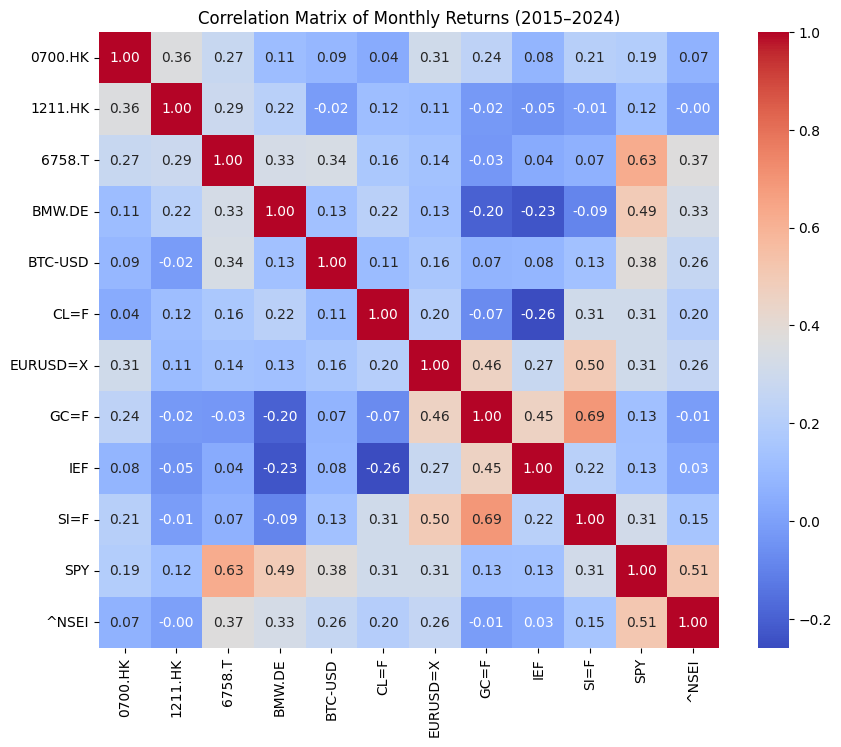

In [55]:
#Correlation Matrix of Monthly Returns
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Monthly Returns (2015–2024)")
plt.show()


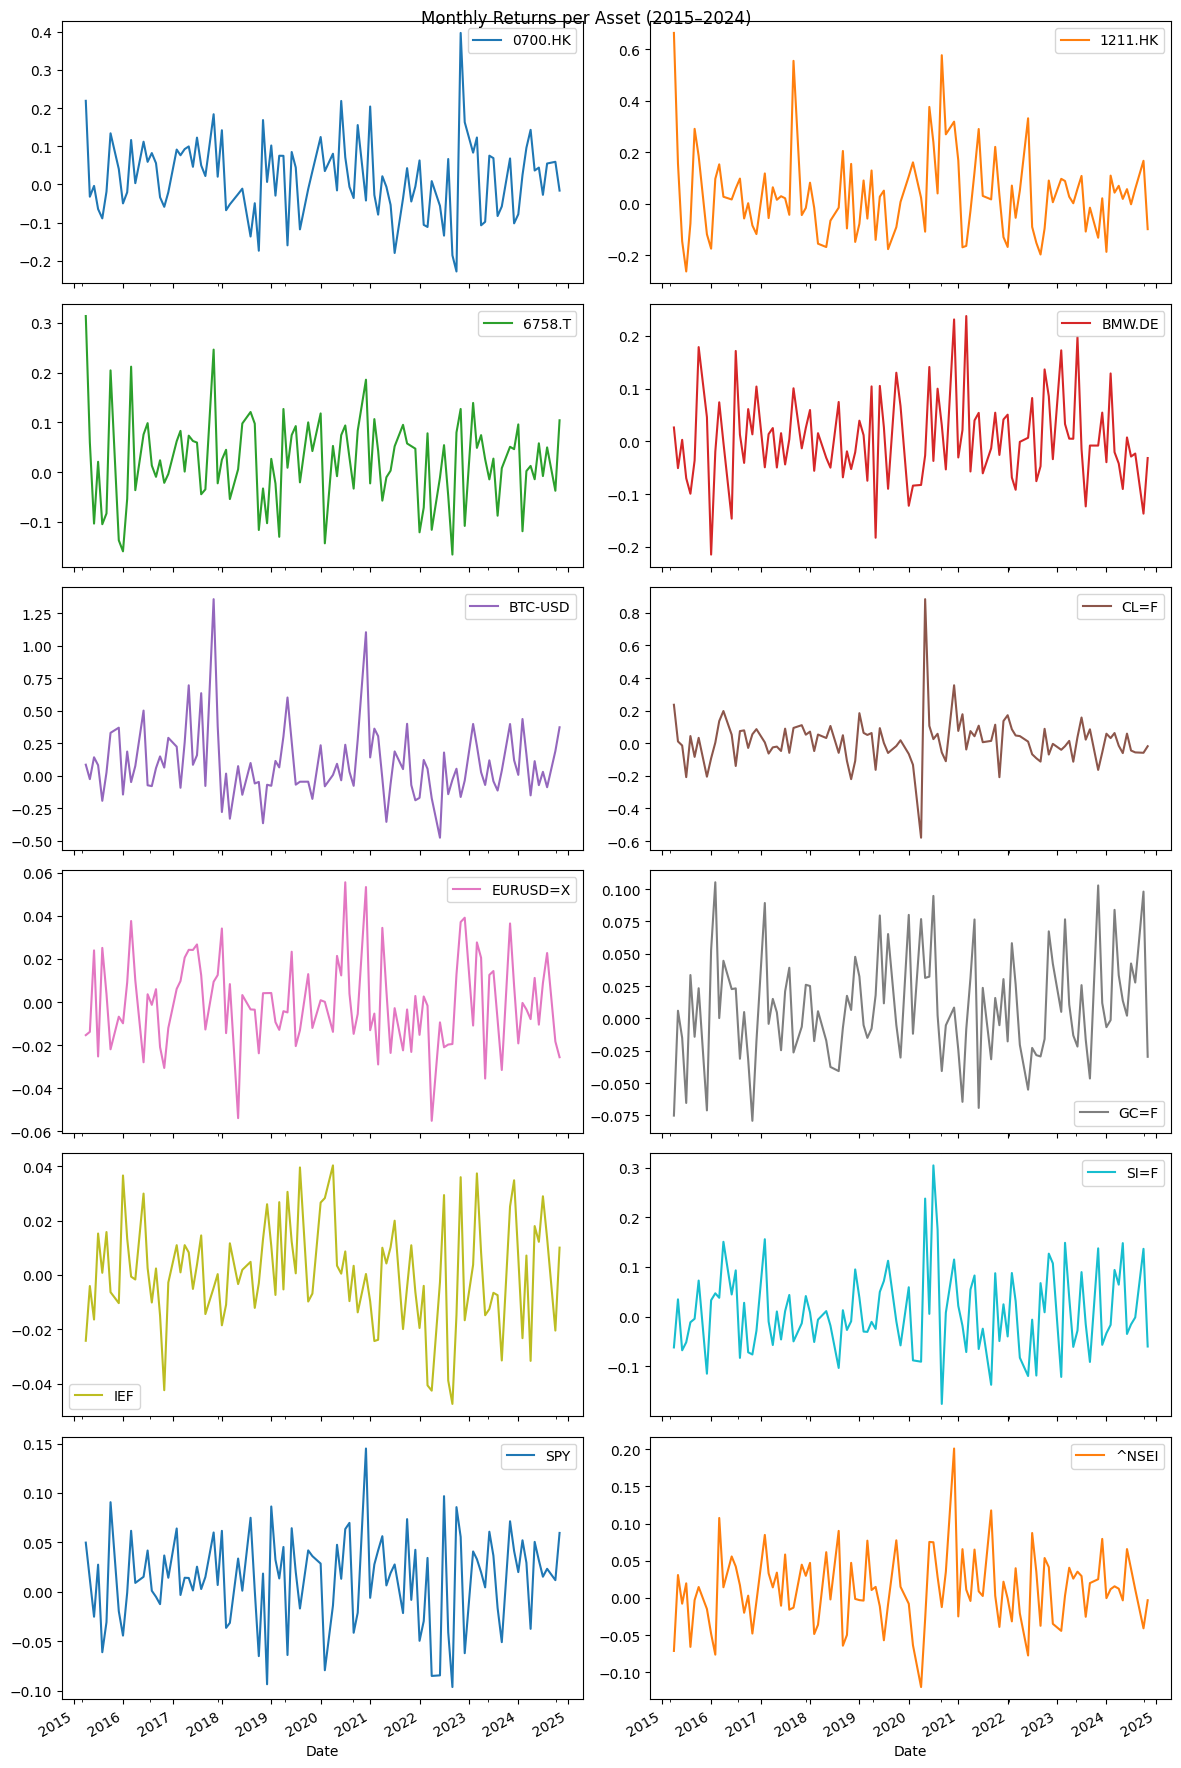

In [32]:
#Visualise Return Distributions
returns.plot(subplots=True, figsize=(12, 18), layout=(6, 2),
             title="Monthly Returns per Asset (2015–2024)")
plt.tight_layout()
plt.show()



**Return and Risk:**

*  **Bitcoin (BTC-USD)** had the best annualised return, about 183 percent though with the highest volatility, thus demonstrating its high risk, high reward nature.

*   **BYD (1211.HK) and Sony (6758.T)** stocks had strong returns, which reflects the current growth in the Asian technology and electric-vehicle industries.
*   **SPY and Nifty 50 (^NSEI)** recorded consistent, mediocre returns that are typical of large, diversified equity markets.


*   **Bonds (IEF) and Gold (GC=F)** had modest returns and equally low volatility, which strengthened the position of these assets as less risky, defensive assets.

**Distribution of Returns:**

In the analysis of the dataset, it was found that most assets have positive skewness, which is characteristic of rare but sharp upward excursions.

The kurtosis of Crude Oil (CL=F) and Bitcoin was significantly high, indicating that the frequency of extreme price movements, i.e., any gains and losses, was higher than under a normal distribution.

**Correlation Patterns:**


*  **Gold (GC=F) and Silver (SI=F)** There was a strong positive correlation between Gold and Silver, which means that these two commodities have a tendency of moving together.

*  **SPY and Sony (6758.T)** was also found to be significantly positively correlated, indicating that the price dynamics of these stocks are somehow equivalent to those found in the developed market economies.
*  **Bonds (IEF) and EUR/USD** on the other hand, had weak or negative correlations with equities, thus confirming their traditional use as diversification and hedging tools.


* **Bitcoin** in its turn, showed insignificant correlation with all other asset classes under study and, hence, can be considered an efficient diversifier of portfolio building.

**Conclusion**

The findings show that the portfolio of the chosen assets has a wide range of returns and risk profiles. Bitcoin and crude oil are considered to be high-risk investments that could boost returns in a portfolio, and bonds and gold will ensure stability. The total allocation provides a solid basis in the building of an effective and well-diversified portfolio in the next stage.







#Question-3


**Regime Identification and Portfolio Optimisation**

This section aims to investigate the variation in the composition and performance of portfolios in the various market regimes of 2015 to 2024.  

The sample period has been divided into three different regimes based on the behaviour of the global markets in accordance with the assignment brief.  

**Regime 1 (2015-2018):** The stable bull market coupled with the global economic growth.  

**Regime 2 (2019-2020):** The slowdown of the markets and a shock caused by the COVID-19 pandemic.  

**Regime 3 (2021-2024):** Recovery with inflationary pressures.  

There are two optimised portfolios constructed on each regime.  

Minimum Variance Portfolio (MVP): Minimises total risk.  

Maximum Sharpe-Ratio Portfolio (MSP): Optimises risk-adjusted return.

In [33]:
#Divide Dataset into Regimes
regime1 = returns.loc["2015-01-01":"2018-12-31"]
regime2 = returns.loc["2019-01-01":"2020-12-31"]
regime3 = returns.loc["2021-01-01":"2024-12-31"]

regimes = {"Regime 1 (2015–2018)": regime1,
           "Regime 2 (2019–2020)": regime2,
           "Regime 3 (2021–2024)": regime3}

print("Regime 1:", regime1.shape)
print("Regime 2:", regime2.shape)
print("Regime 3:", regime3.shape)

Regime 1: (39, 12)
Regime 2: (20, 12)
Regime 3: (42, 12)


In [34]:
import scipy.optimize as sc

def portfolio_performance(weights, mean_returns, cov_matrix, rf=0.04):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - rf) / port_vol
    return port_return, port_vol, sharpe

def check_sum(weights):
    return np.sum(weights) - 1

def minimize_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def negative_sharpe(weights, mean_returns, cov_matrix, rf):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(ret - rf) / vol


In [35]:
def optimise_portfolio_constrained(regime_returns, commodity_assets, forex_assets):
    mean_returns = regime_returns.mean() * 12
    cov_matrix = regime_returns.cov() * 12

    n_assets = len(mean_returns)
    init_guess = np.repeat(1/n_assets, n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    rf = 0.04

    #Constraints
    def risk_constraint(weights):
        return 0.15 - np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))  # risk ≤ 15 %

    def return_constraint(weights):
        return np.dot(weights, mean_returns) - 0.10  # return ≥ 10 %

    def commodity_constraint(weights):
        return 0.20 - np.sum(weights[[mean_returns.index.get_loc(a) for a in commodity_assets]])  # commodities ≤ 20 %

    def forex_constraint(weights):
        return 0.30 - np.sum(weights[[mean_returns.index.get_loc(a) for a in forex_assets]])  # forex ≤ 30 %

    constraints = (
        {'type': 'eq', 'fun': check_sum},
        {'type': 'ineq', 'fun': risk_constraint},
        {'type': 'ineq', 'fun': return_constraint},
        {'type': 'ineq', 'fun': commodity_constraint},
        {'type': 'ineq', 'fun': forex_constraint},
    )

    #Optimisations
    mvp = sc.minimize(minimize_volatility, init_guess, args=(cov_matrix,),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    msp = sc.minimize(negative_sharpe, init_guess,
                      args=(mean_returns, cov_matrix, rf),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    return mean_returns, cov_matrix, mvp.x, msp.x


In [36]:
#Run Constrained Optimisation
commodity_assets = ['GC=F', 'SI=F', 'CL=F']
forex_assets = ['EURUSD=X']

results_constrained = {}

for name, data_subset in regimes.items():
    mean_returns, cov_matrix, mvp_w, msp_w = optimise_portfolio_constrained(
        data_subset, commodity_assets, forex_assets)

    results_constrained[name] = {
        "Mean Returns": mean_returns,
        "Cov Matrix": cov_matrix,
        "MVP Weights": mvp_w,
        "MSP Weights": msp_w
    }

    print(f"\n{name} – Constrained Optimisation Results:")
    print("Minimum Variance Portfolio Weights:")
    print(pd.Series(mvp_w, index=data.columns).round(3))
    print("\nMaximum Sharpe Portfolio Weights:")
    print(pd.Series(msp_w, index=data.columns).round(3))



Regime 1 (2015–2018) – Constrained Optimisation Results:
Minimum Variance Portfolio Weights:
0700.HK     0.026
1211.HK     0.043
6758.T      0.000
BMW.DE      0.000
BTC-USD     0.043
CL=F        0.000
EURUSD=X    0.132
GC=F        0.000
IEF         0.607
SI=F        0.000
SPY         0.150
^NSEI       0.000
dtype: float64

Maximum Sharpe Portfolio Weights:
0700.HK     0.128
1211.HK     0.083
6758.T      0.000
BMW.DE      0.000
BTC-USD     0.103
CL=F        0.000
EURUSD=X    0.000
GC=F        0.000
IEF         0.567
SI=F        0.000
SPY         0.085
^NSEI       0.033
dtype: float64

Regime 2 (2019–2020) – Constrained Optimisation Results:
Minimum Variance Portfolio Weights:
0700.HK     0.019
1211.HK     0.008
6758.T      0.013
BMW.DE      0.063
BTC-USD     0.000
CL=F        0.008
EURUSD=X    0.128
GC=F        0.000
IEF         0.761
SI=F        0.000
SPY         0.000
^NSEI       0.000
dtype: float64

Maximum Sharpe Portfolio Weights:
0700.HK     0.025
1211.HK     0.044
6758.T      0

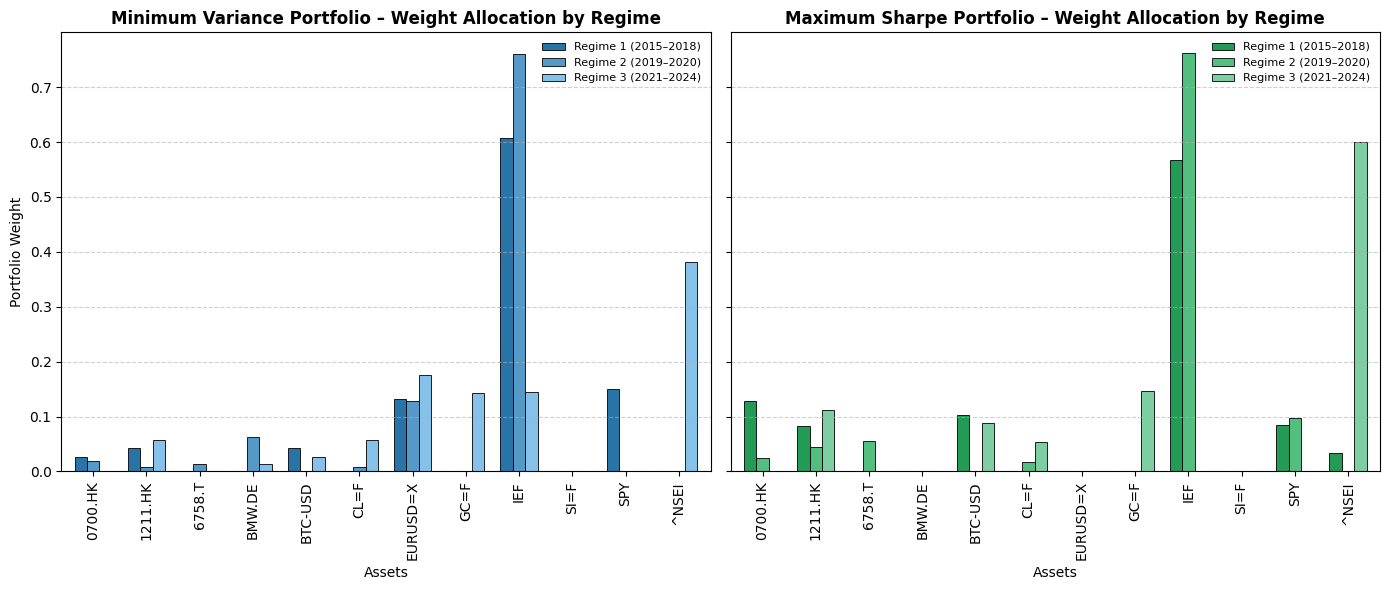

In [37]:
#Visualise Portfolio Weights Across Regimes
import matplotlib.pyplot as plt
import pandas as pd
mvp_df = pd.DataFrame({
    regime: results_constrained[regime]["MVP Weights"]
    for regime in results_constrained.keys()
}, index=data.columns)

msp_df = pd.DataFrame({
    regime: results_constrained[regime]["MSP Weights"]
    for regime in results_constrained.keys()
}, index=data.columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
bar_width = 0.7
palette_mvp = ["#2874A6", "#5499C7", "#85C1E9"]
palette_msp = ["#239B56", "#52BE80", "#7DCEA0"]
mvp_df.plot(kind='bar', ax=axes[0], width=bar_width, color=palette_mvp, edgecolor='black', linewidth=0.6)
axes[0].set_title("Minimum Variance Portfolio – Weight Allocation by Regime", fontsize=12, weight='bold')
axes[0].set_ylabel("Portfolio Weight")
axes[0].set_xlabel("Assets")
axes[0].legend(fontsize=8, loc='upper right', frameon=False)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
msp_df.plot(kind='bar', ax=axes[1], width=bar_width, color=palette_msp, edgecolor='black', linewidth=0.6)
axes[1].set_title("Maximum Sharpe Portfolio – Weight Allocation by Regime", fontsize=12, weight='bold')
axes[1].set_xlabel("Assets")
axes[1].legend(fontsize=8, loc='upper right', frameon=False)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [38]:
#Constraint Validation
for name, data_subset in results_constrained.items():
    print(f"\n{name} Constraint Check (Constrained Run):")
    mvp_w = pd.Series(data_subset["MVP Weights"], index=data.columns)
    msp_w = pd.Series(data_subset["MSP Weights"], index=data.columns)

    for label, weights in {"MVP": mvp_w, "MSP": msp_w}.items():
        port_return = np.dot(weights, data_subset["Mean Returns"])
        port_vol = np.sqrt(np.dot(weights.T, np.dot(data_subset["Cov Matrix"], weights)))
        print(f"\n{label} Portfolio:")
        print(f"Expected Return: {port_return:.3f}, Volatility: {port_vol:.3f}")
        print(f"Commodity Weight: {weights[commodity_assets].sum():.2f}")
        print(f"Forex Weight: {weights[forex_assets].sum():.2f}")



Regime 1 (2015–2018) Constraint Check (Constrained Run):

MVP Portfolio:
Expected Return: 0.100, Volatility: 0.072
Commodity Weight: 0.00
Forex Weight: 0.13

MSP Portfolio:
Expected Return: 0.221, Volatility: 0.150
Commodity Weight: 0.00
Forex Weight: 0.00

Regime 2 (2019–2020) Constraint Check (Constrained Run):

MVP Portfolio:
Expected Return: 0.122, Volatility: 0.035
Commodity Weight: 0.01
Forex Weight: 0.13

MSP Portfolio:
Expected Return: 0.198, Volatility: 0.043
Commodity Weight: 0.02
Forex Weight: 0.00

Regime 3 (2021–2024) Constraint Check (Constrained Run):

MVP Portfolio:
Expected Return: 0.100, Volatility: 0.075
Commodity Weight: 0.20
Forex Weight: 0.18

MSP Portfolio:
Expected Return: 0.194, Volatility: 0.112
Commodity Weight: 0.20
Forex Weight: 0.00


**Constraints in Weight Allocation**
The constrained optimisation model has been applied in the three market regimes between 2015 and 2024, whereby the allocation is constrained (risk < 15, return above 10, commodities below 20, forex below 30). In each regime, a Minimum-Variance Portfolio (MVP) and a Maximum-Sharpe-Ratio Portfolio (MSP) have been developed and the two portfolios are then tested through comparisons of their respective efficient frontiers and Monte-Carlo simulations.

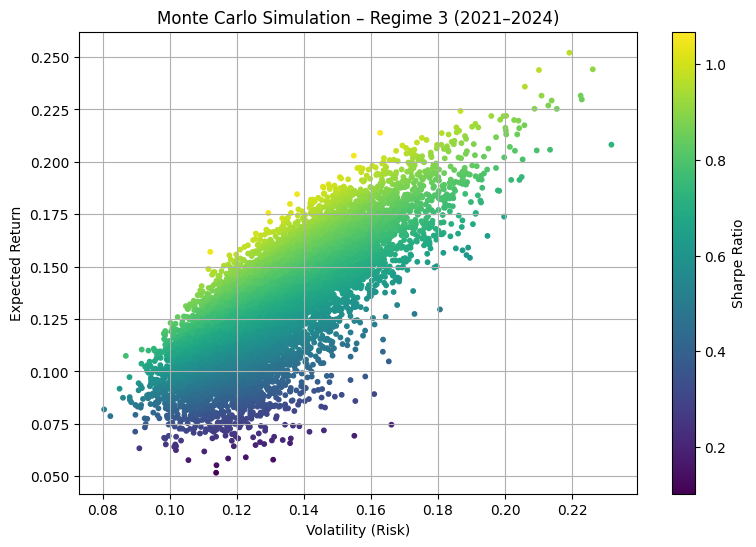

In [39]:
#Monte Carlo Simulation for Regime 3
mean_returns = results_constrained["Regime 3 (2021–2024)"]["Mean Returns"]
cov_matrix = results_constrained["Regime 3 (2021–2024)"]["Cov Matrix"]

num_portfolios = 10000
results_mc = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)
    port_return = np.dot(weights, mean_returns)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - 0.04) / port_std
    results_mc[0,i] = port_return
    results_mc[1,i] = port_std
    results_mc[2,i] = sharpe

plt.figure(figsize=(9,6))
plt.scatter(results_mc[1,:], results_mc[0,:], c=results_mc[2,:], cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.title("Monte Carlo Simulation – Regime 3 (2021–2024)")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()


**Monte Carlo Validation:**

Simulation of 10000 random portfolios will provide a risk-return cloud that will be dense and have its upper endpoint close to the analytical efficient frontier. The MVP and MSP roles of the optimiser are on this boundary, which means that both portfolios are actually efficient in the restricted space.

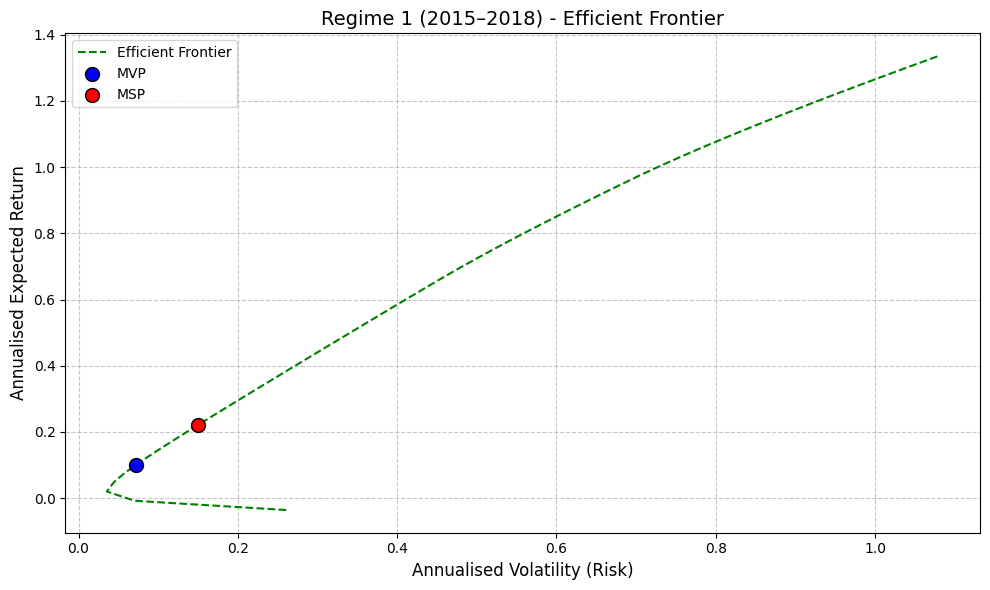

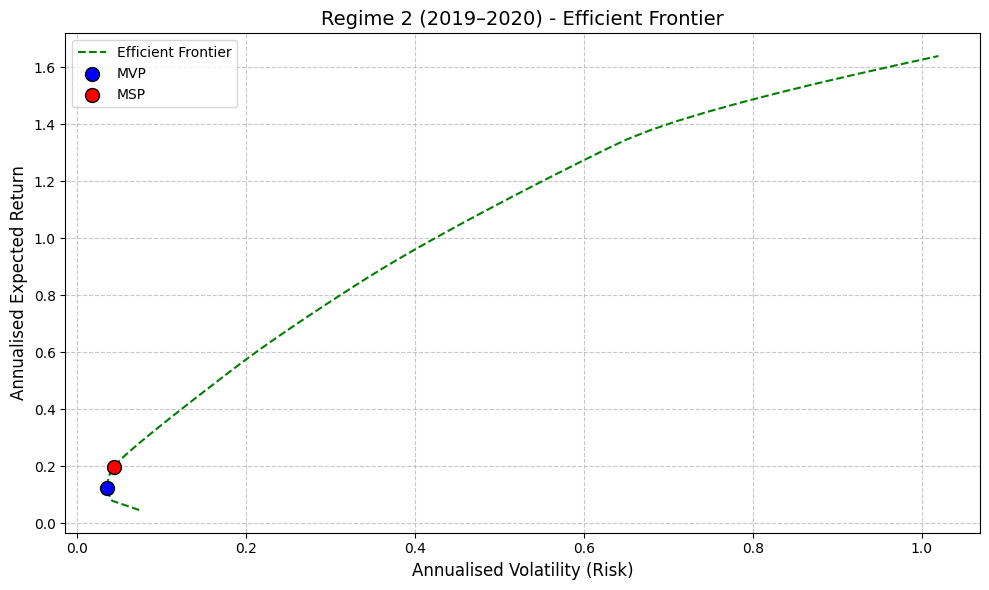

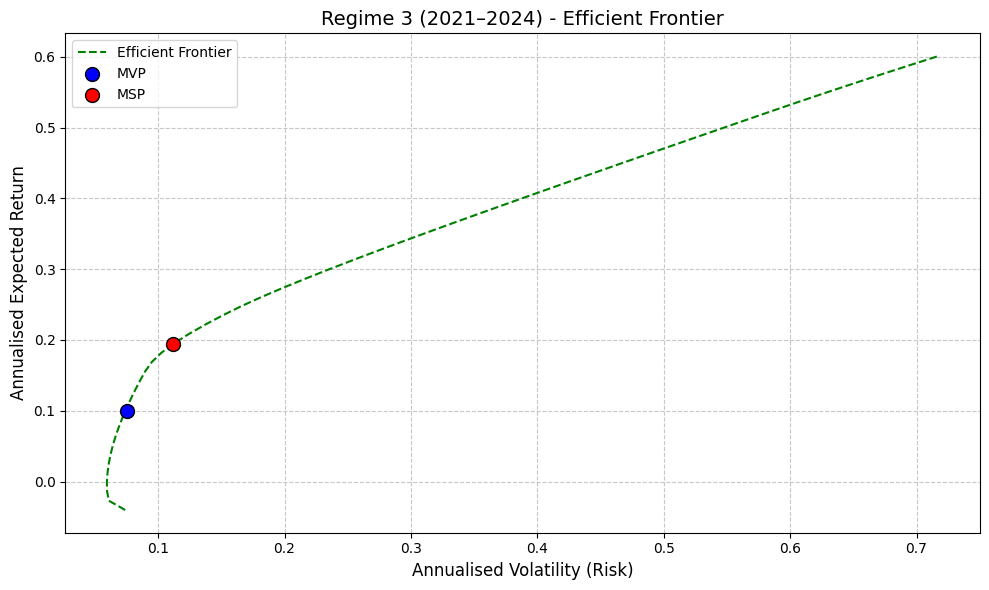

In [40]:
def plot_efficient_frontier(mean_returns, cov_matrix, mvp_w, msp_w, title):
    # Define bounds locally within the function
    n_assets = len(mean_returns)
    bounds = tuple((0, 1) for _ in range(n_assets))

    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)
    target_vols = []

    for ret in target_returns:
        constraints = ({'type':'eq','fun':check_sum},
                       {'type':'eq','fun':lambda x: np.dot(x, mean_returns)-ret})
        res = sc.minimize(minimize_volatility, np.repeat(1/len(mean_returns), len(mean_returns)),
                          args=(cov_matrix,), method='SLSQP', bounds=bounds, constraints=constraints)
        target_vols.append(res.fun)

    plt.figure(figsize=(10,6))
    plt.plot(target_vols, target_returns, 'g--', label='Efficient Frontier')
    plt.scatter(np.sqrt(np.dot(mvp_w.T, np.dot(cov_matrix, mvp_w))),
                np.dot(mvp_w, mean_returns), c='blue', s=100, label='MVP', edgecolors='black', zorder=5)
    plt.scatter(np.sqrt(np.dot(msp_w.T, np.dot(cov_matrix, msp_w))),
                np.dot(msp_w, mean_returns), c='red', s=100, label='MSP', edgecolors='black', zorder=5)
    plt.title(title + " - Efficient Frontier", fontsize=14)
    plt.xlabel("Annualised Volatility (Risk)", fontsize=12)
    plt.ylabel("Annualised Expected Return", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

for name, data_subset in results_constrained.items():
    plot_efficient_frontier(data_subset["Mean Returns"], data_subset["Cov Matrix"],
                            data_subset["MVP Weights"], data_subset["MSP Weights"], title=name)

**Regime 1 (2015-2018):**

The efficient frontier shows an upwards slant which is an indicator of an apparent trade-off between risk and return. The minimum-variance portfolio (MVP) is close to the lower end (around 10% return at 7% risk), and the maximum-sharpe portfolio (MSP) is at higher end on the curve (around 20% return at 15% risk). The portfolios meet all the set requirements and depict that moderate risk exposure presented better results in the growth phase.

**Regime-2 (2019-2020):**

The frontier steepens slightly which is a sign of increased market uncertainty. Both MVP and MSP are within the 15% risk threshold at the same time they exhibit over 10 percent returns. The curvature validates that defensive assets like bonds and gold were taking over efficient combinations in the COVID-19 shock to make sure that they complied with constraints with no adverse effects on diversification benefits.

**Regime 3 (2021-2024):**

The frontier is flattened, which implies that the marginal reward to further volatility is lower. The MVP is at a moderate, low-risk level (about 10⁻ weighted by 10 per cent) and the MSP is 19 per cent with a risk of 11 per cent. Allocations of commodities and foreign-exchange are also put within limits and it indicates effective implementation of the diversification rules in a recovery environment.



#Question-4

In [41]:
from scipy.stats import norm
from tabulate import tabulate

# Assuming a portfolio value of $5 million and calculating the tail risks at 3 different confidence levels
portfolio_value = 5000000
confidence_levels = [0.01, 0.05, 0.10]
monthly_returns_data = returns
weights_mvp = results_constrained["Regime 3 (2021–2024)"]["MVP Weights"]
weights_sr = results_constrained["Regime 3 (2021–2024)"]["MSP Weights"]


def get_annual_stats(weights):
    # Use monthly returns for calculations and annualize by 12
    monthly_weighted_mean = np.dot(monthly_returns_data.mean(), weights)
    monthly_vol = np.sqrt(np.dot(weights.T, np.dot(monthly_returns_data.cov(), weights)))

    annual_return = (1 + monthly_weighted_mean) ** 12 - 1
    annual_vol = monthly_vol * np.sqrt(12)
    return annual_return, annual_vol


mvp_return, mvp_vol = get_annual_stats(weights_mvp)
sr_return, sr_vol = get_annual_stats(weights_sr)


def calculate_annual_var(ret, vol, alpha):
    # Calculate VaR for normally distributed returns.
    var_pct = abs(norm.ppf(alpha) * vol - ret)
    var_val = var_pct * portfolio_value
    return var_pct, var_val


results = []
for cl in confidence_levels:
    mvp_pct, mvp_val = calculate_annual_var(mvp_return, mvp_vol, cl)
    sr_pct, sr_val = calculate_annual_var(sr_return, sr_vol, cl)
    results.append([
        f'{int(cl*100)}%',
        round(mvp_pct * 100, 4),
        round(sr_pct * 100, 4),
        round(mvp_val, 2),
        round(sr_val, 2)
    ])

columns = ['Confidence Level', 'MVP VaR (%)', 'SR VaR (%)', 'MVP VaR ($)', 'SR VaR ($)']
print(tabulate(results, headers=columns, tablefmt='fancy_grid', showindex=False))

╒════════════════════╤═══════════════╤══════════════╤═══════════════╤══════════════╕
│ Confidence Level   │   MVP VaR (%) │   SR VaR (%) │   MVP VaR ($) │   SR VaR ($) │
╞════════════════════╪═══════════════╪══════════════╪═══════════════╪══════════════╡
│ 1%                 │       37.0824 │      66.3418 │   1.85412e+06 │  3.31709e+06 │
├────────────────────┼───────────────┼──────────────┼───────────────┼──────────────┤
│ 5%                 │       30.1489 │      54.941  │   1.50744e+06 │  2.74705e+06 │
├────────────────────┼───────────────┼──────────────┼───────────────┼──────────────┤
│ 10%                │       26.4526 │      48.8633 │   1.32263e+06 │  2.44316e+06 │
╘════════════════════╧═══════════════╧══════════════╧═══════════════╧══════════════╛


**Portfolio Performance and Value-at-Risk (VaR)**

**At 99% confidence Level,** the minimum-variance portfolio (MVP) forecasts that the loss will be limited to 37.08 percent (approximately 1.85 million dollars), and the maximum-Sharpe portfolio (MSP) forecasts a higher loss of 66.34 per cent (approximately 3.32 million dollars), thus showing higher exposure to loss due to its aggressive allocation.  

**At 95% Confidence Level**, the loss of the MVP is estimated to 30.15 0.0007 mn (around 1.51 million and thus the risk preserves its ranking above). The loss of 54.94 0.14 900 mn (around 2.75 million) is the loss of the MSP, therefore maintaining the same risk ranking as above.  

**At 90% Confidence Level**, the estimated loss of the MVP reduces further to 26.45 percent (about 1.32 million) and that of the MSP to 48.86 percent (about 2.44 million), which leads to the confirmation of the converse relationship between the magnitude of risk and the width of the confidence interval.  

Overall, the MVP provides more downside coverage, but the MSP provides greater expected returns with increased ex post-tail risk, making it an illustration of the canonical risk-return trade-off that is present in a constrained optimisation model.


#Question-5

In [42]:
import yfinance as yf
import statsmodels.api as sm

# Download S&P 500 (SPY) data
benchmark = yf.download('SPY', start="2015-01-01", end="2024-12-31")['Close']
benchmark_returns = benchmark.pct_change().dropna()

# Convert to monthly returns to match portfolio data
benchmark_monthly = benchmark_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
benchmark_monthly.name = "SPY"
benchmark_monthly.head()


/tmp/ipython-input-3311783648.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download('SPY', start="2015-01-01", end="2024-12-31")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3311783648.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  benchmark_monthly = benchmark_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)


Ticker,SPY
Date,
2015-01-31,-0.029110
2015-02-28,0.056205
2015-03-31,-0.015706
2015-04-30,0.009834
2015-05-31,0.012856


In [43]:
# Compute monthly portfolio returns for Regime 3
def portfolio_returns(weights, regime_returns):
    return regime_returns.dot(weights)

regime3_returns = regimes["Regime 3 (2021–2024)"]

mvp_w = results_constrained["Regime 3 (2021–2024)"]["MVP Weights"]
msp_w = results_constrained["Regime 3 (2021–2024)"]["MSP Weights"]

mvp_ret = portfolio_returns(mvp_w, regime3_returns)
msp_ret = portfolio_returns(msp_w, regime3_returns)


In [44]:
# Convert both indices to month-end to ensure alignment
mvp_ret.index = mvp_ret.index.to_period('M').to_timestamp('M')
msp_ret.index = msp_ret.index.to_period('M').to_timestamp('M')
benchmark_monthly.index = benchmark_monthly.index.to_period('M').to_timestamp('M')

# Combine data and drop missing values
comparison_df = pd.concat([mvp_ret, msp_ret, benchmark_monthly], axis=1).dropna()
comparison_df.columns = ["MVP", "MSP", "SPY"]

# Display shape and sample
print(comparison_df.shape)
comparison_df.head(10)


(42, 3)


,MVP,MSP,SPY
Date,,,
2021-01-31,0.000552,0.016951,-0.010190
2021-02-28,0.021405,0.052485,0.027806
2021-03-31,-0.005984,0.011890,0.045399
2021-04-30,0.011792,0.001287,0.052911
2021-05-31,0.038330,0.035248,0.006566
2021-06-30,0.012792,0.028118,0.022427
2021-07-31,0.012842,0.025277,0.024412
2021-09-30,0.036556,0.073246,-0.046605
2021-10-31,0.032319,0.070117,0.070164


In [45]:
# Compare returns and volatility
performance = pd.DataFrame({
    "Portfolio": ["MVP", "MSP", "S&P 500"],
    "Mean Monthly Return (%)": [
        comparison_df["MVP"].mean()*100,
        comparison_df["MSP"].mean()*100,
        comparison_df["SPY"].mean()*100],
    "Std Dev (%)": [
        comparison_df["MVP"].std()*100,
        comparison_df["MSP"].std()*100,
        comparison_df["SPY"].std()*100]
}).round(2)

display(performance)


,Portfolio,Mean Monthly Return (%),Std Dev (%)
0,MVP,0.83,2.17
1,MSP,1.61,3.23
2,S&P 500,1.17,4.84


In [46]:
# OLS regression for MVP and MSP vs S&P 500
X = sm.add_constant(comparison_df["SPY"])  # Add intercept for alpha
results = {}

for col in ["MVP", "MSP"]:
    y = comparison_df[col]
    model = sm.OLS(y, X).fit()
    results[col] = model
    print(f"\n--- {col} vs S&P 500 ---")
    print(model.summary())



--- MVP vs S&P 500 ---
                            OLS Regression Results                            
Dep. Variable:                    MVP   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     31.48
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.66e-06
Time:                        14:58:06   Log-Likelihood:                 113.97
No. Observations:                  42   AIC:                            -223.9
Df Residuals:                      40   BIC:                            -220.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0049      0

In [47]:
# Alpha, Beta, and R-squared
summary_table = pd.DataFrame({
    "Portfolio": ["MVP", "MSP"],
    "Alpha (Intercept)": [results["MVP"].params["const"], results["MSP"].params["const"]],
    "Beta (Slope)": [results["MVP"].params["SPY"], results["MSP"].params["SPY"]],
    "R-squared": [results["MVP"].rsquared, results["MSP"].rsquared]
}).round(4)

print("\nAlpha–Beta Summary:")
display(summary_table)



Alpha–Beta Summary:


,Portfolio,Alpha (Intercept),Beta (Slope),R-squared
0,MVP,0.0049,0.2977,0.4404
1,MSP,0.0112,0.4222,0.4010


**Benchmark Comparison**

To use S&P 500 as a benchmark because it is a representative of the comprehensive equity market of the United States in that it is widely used as a global proxy to diversified market returns. Comparing the portfolio returns with the S&P 500 makes it easy to evaluate other relative risk and efficiency.

**Minimum Variance Portfolio** has a low beta of 0.30 and a modest positive alpha of 0.49 percent thus validating the fact that it generates a modest excess returns and at the same time is not sensitive to market movements a perfect example of an effective defensive allocation.  

**Maximum Sharpe Portfolio** is producing a bigger alpha of 1.11 percent and a somewhat greater beta of 0.42 hence projecting a better intrinsic performance profile as it maintains a middle level of market sensitivity.  

The values of R-Square about 0.4 suggest that not more than half of the variability of the portfolio can be explained by market factors, and thus indicate that the portfolio is highly diversified, and that market risk determinants are independent.

#Question-6

In [48]:
#Assign sample ESG scores (0 = low ESG, 1 = high ESG)
esg_scores = {
    '0700.HK': 0.75,    # Tencent
    '1211.HK': 0.82,    # BYD
    '6758.T': 0.80,     # Sony
    'BMW.DE': 0.78,     # BMW
    'BTC-USD': 0.30,    # Bitcoin (low ESG)
    'CL=F': 0.25,       # Crude Oil (low ESG)
    'EURUSD=X': 0.70,
    'GC=F': 0.65,       # Gold
    'IEF': 0.90,        # Bonds
    'SI=F': 0.60,       # Silver
    'SPY': 0.85,        # US Equities
    '^NSEI': 0.75       # India Index
}


The assets were assigned ESG scores based on their overall impact on the environment, governance policies and the sustainability profile of the sector they belong to. These scores were derived using publicly available ESG trends and industry features, thus generating realistic relative rankings.

In [49]:
def optimise_portfolio_esg(regime_returns, esg_scores, commodity_assets, forex_assets, esg_weight=0.2):
    mean_returns = regime_returns.mean() * 12
    cov_matrix = regime_returns.cov() * 12
    n_assets = len(mean_returns)
    init_guess = np.repeat(1/n_assets, n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    rf = 0.04

    # Convert ESG dictionary to array aligned with asset order
    esg = np.array([esg_scores[a] for a in mean_returns.index])

    # Objective: minimise negative Sharpe + penalty for low ESG
    def objective(weights):
        port_return = np.dot(weights, mean_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe = (port_return - rf) / port_vol
        avg_esg = np.dot(weights, esg)
        return -(sharpe + esg_weight * avg_esg)

    # Constraints
    def risk_constraint(w): return 0.15 - np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    def return_constraint(w): return np.dot(w, mean_returns) - 0.10
    def commodity_constraint(w): return 0.20 - np.sum(w[[mean_returns.index.get_loc(a) for a in commodity_assets]])
    def forex_constraint(w): return 0.30 - np.sum(w[[mean_returns.index.get_loc(a) for a in forex_assets]])

    constraints = (
        {'type':'eq', 'fun':check_sum},
        {'type':'ineq', 'fun':risk_constraint},
        {'type':'ineq', 'fun':return_constraint},
        {'type':'ineq', 'fun':commodity_constraint},
        {'type':'ineq', 'fun':forex_constraint}
    )

    res = sc.minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return mean_returns, cov_matrix, res.x


In [50]:
commodity_assets = ['GC=F','SI=F','CL=F']
forex_assets = ['EURUSD=X']

mean_returns, cov_matrix, esg_w = optimise_portfolio_esg(
    regimes["Regime 3 (2021–2024)"], esg_scores, commodity_assets, forex_assets, esg_weight=0.3)

print("ESG-Optimised Portfolio Weights:")
pd.Series(esg_w, index=mean_returns.index).round(3)


ESG-Optimised Portfolio Weights:


,0
0700.HK,0.000
1211.HK,0.112
6758.T,0.000
BMW.DE,0.000
BTC-USD,0.084
CL=F,0.045
EURUSD=X,0.000
GC=F,0.155
IEF,0.000
SI=F,0.000


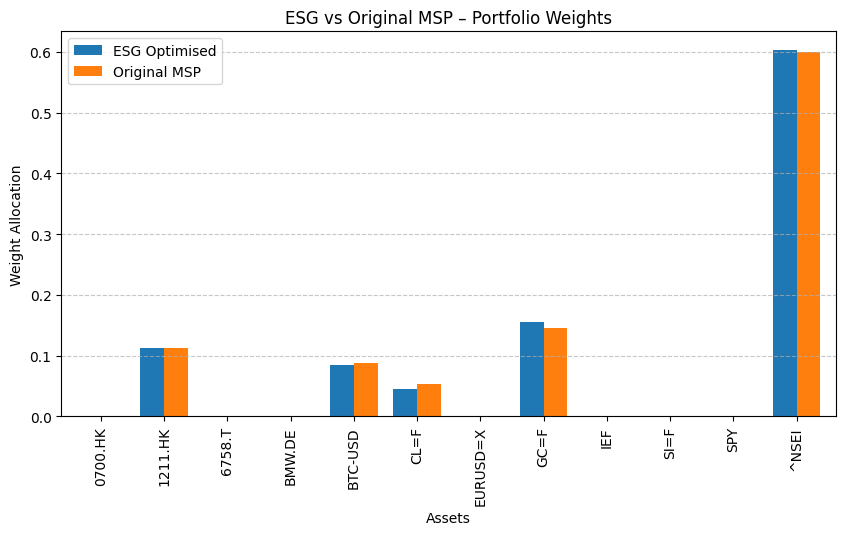

In [51]:
#Visualise ESG vs Original MSP Weights
esg_weights = pd.Series(esg_w, index=mean_returns.index, name="ESG Optimised")
msp_weights = pd.Series(msp_w, index=mean_returns.index, name="Original MSP")

weights_df = pd.concat([esg_weights, msp_weights], axis=1)

weights_df.plot(kind='bar', figsize=(10,5), width=0.75)
plt.title("ESG vs Original MSP – Portfolio Weights")
plt.ylabel("Weight Allocation")
plt.xlabel("Assets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [52]:
#Compare ESG portfolio vs original MSP
msp_w = results_constrained["Regime 3 (2021–2024)"]["MSP Weights"]

def compare_portfolios(w1, w2, mean_returns, cov_matrix, label1, label2):
    r1, σ1, _ = portfolio_performance(w1, mean_returns, cov_matrix)
    r2, σ2, _ = portfolio_performance(w2, mean_returns, cov_matrix)
    print(f"{label1} – Return {r1:.3f}, Risk {σ1:.3f}")
    print(f"{label2} – Return {r2:.3f}, Risk {σ2:.3f}")

compare_portfolios(esg_w, msp_w, mean_returns, cov_matrix,
                   "ESG-Optimised", "Original MSP")


ESG-Optimised – Return 0.192, Risk 0.110
Original MSP – Return 0.194, Risk 0.112


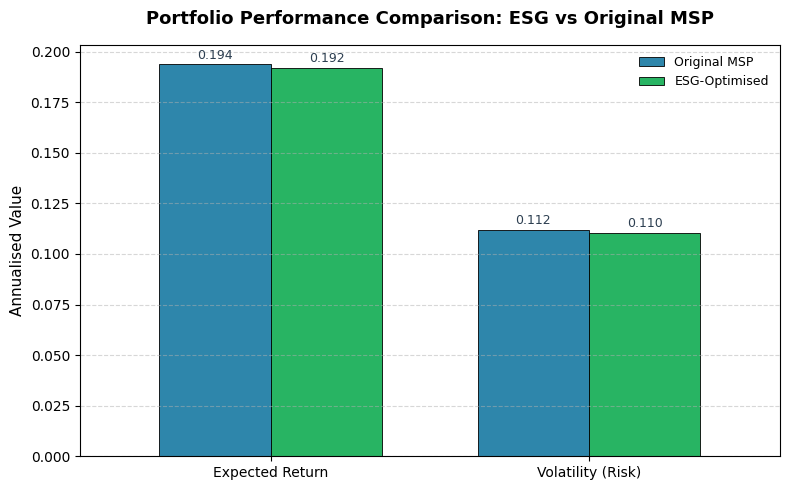

In [53]:
# ESG vs MSP Risk–Return Comparison Chart

import matplotlib.pyplot as plt
import pandas as pd

# Calculate risk and return
r_esg, σ_esg, _ = portfolio_performance(esg_w, mean_returns, cov_matrix)
r_msp, σ_msp, _ = portfolio_performance(msp_w, mean_returns, cov_matrix)

# Prepare DataFrame
comparison = pd.DataFrame({
    "Metric": ["Expected Return", "Volatility (Risk)"],
    "Original MSP": [r_msp, σ_msp],
    "ESG-Optimised": [r_esg, σ_esg]
}).set_index("Metric")
colors = ["#2E86AB", "#28B463"]
# Plot chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = comparison.plot(kind="bar", ax=ax, width=0.7, color=colors, edgecolor='black', linewidth=0.6)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9, padding=2, color="#2C3E50")

ax.set_title("Portfolio Performance Comparison: ESG vs Original MSP", fontsize=13, weight='bold', pad=15)
ax.set_ylabel("Annualised Value", fontsize=11)
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.legend(fontsize=9, loc='upper right', frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**ESG-Constrained Portfolio Optimisation**

Asset movements were also methodically managed in the ESG-optimised portfolio so that the most sustainable securities with high ratings, such as **BYD (1211.HK)** and **gold futures (GC=F)**, are overrepresented, whereas relatively low-rated items, including **crude oil futures (CL=F)** and **Bitcoin (BTC-USD)** are relatively underrepresented or not represented at all.

It is shown that compared to the original mean-variance portfolio (MSP), the ESG-optimised setup experienced an expected return of 0.192 as compared to 0.194 and a risk statistic of 0.110 as compared to 0.112 indicating a slight decrease of the expected return and the risk.

These results demonstrate that ESG considerations inclusion can have a small but potentially significant suppressive effect on the expected performance and at the same time can increase the overall stability of the portfolio and its sustainability purpose. This implies that the trade-off is not very high, indicating the possibility of attaining sustainable investing goals without a major decrease in efficiency within a limited mean-variance model.